# Permutation testing — thickness-subset

Companion to `paper_models.ipynb`. Here the **volume** and **surface-area** models are
refit on **only the subjects that have whole-brain SP thickness available** — i.e. the
exact sample the thickness models (`T_GA_thk`, `T_acq_thk`) are fit on (N = 13 per split pair).

In `paper_models.ipynb` the volume/surface models use the full GA ≤ 32 sample (N = 20 per
pair) while thickness uses a smaller sample (N = 13). That makes the three outcomes not
directly comparable. This notebook removes that confound by putting all outcomes on the
**same 13 subjects per pair**, so differences in the fits reflect the outcome, not the sample.

The **thickness models (`T_GA_thk`, `T_acq_thk`) are included unchanged** from
`paper_models.ipynb` — they were already fit on this 13-subject sample — plus a **relative**
variant (`T_GA_rel_thk`, `T_acq_rel_thk`) fit on the percent thickness difference (`apd_thk`)
instead of the absolute difference (`thk_diff`, mm). The cross-model comparison at the end
therefore covers all outcomes (volume, surface, absolute thickness, relative thickness) on an
identical sample.

Every model in this notebook carries a **`_thk` suffix** (`M_GA_thk`, `M_acq_thk`,
`S_GA_thk`, `S_acq_thk`, `T_GA_thk`, `T_acq_thk`, `T_GA_rel_thk`, `T_acq_rel_thk`) to mark it
as the thickness-subset variant and keep it distinct from the full-sample models in
`paper_models.ipynb`.

Everything else — GA ≤ 32 restriction, the two split pairs (S1-S2, S3-S4) as independent
replications, predictors (`GA`, `qa_mean`, `stack_count`), and the diagnostics — matches
`paper_models.ipynb`. The thickness subject set differs slightly between the two pairs, so
each pair's volume/surface frame is restricted to *that pair's* thickness subjects.

In [16]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from slides_helpers import diagnostics_grid, fit_and_present, model_comparison_table

DATA = Path('../data')
ASSETS = Path('../assets')
ARTIFACTS = Path('../assets/artifacts')
ASSETS.mkdir(exist_ok=True)
ARTIFACTS.mkdir(parents=True, exist_ok=True)

plt.rcParams['figure.dpi'] = 110
pd.set_option('display.float_format', lambda x: f'{x:.3f}')

## Load data and build per-pair analysis frames

Same four CSVs and the same `build_pair` construction as `paper_models.ipynb`. The volume
and surface frames (`s12`, `s34`) start at N = 20 per pair and are then restricted to the
thickness subjects below.

In [17]:
raw = pd.read_csv(DATA / 'raw_subject_data.csv')
splits_df = pd.read_csv(DATA / 'split_comparision_data.csv')
iqm = pd.read_csv(DATA / 'image_quality_metrics.csv')

# Restrict to GA <= 32 weeks (drops 3 late-GA subjects: FCB070, FCB184, FCB187)
GA_MAX = 32
_keep = raw.loc[raw['GA'] <= GA_MAX, ['subject_id', 'session_id']]
raw = raw.merge(_keep, on=['subject_id', 'session_id'], how='inner')
splits_df = splits_df.merge(_keep, on=['subject_id', 'session_id'], how='inner')
iqm = iqm.merge(_keep, on=['subject_id', 'session_id'], how='inner')

# QA differences within each pair (paper's 'quality difference')
raw['qa_diff_S1S2'] = (raw['QA_S1'] - raw['QA_S2']).abs()
raw['qa_diff_S3S4'] = (raw['QA_S3'] - raw['QA_S4']).abs()

# Surface-homogeneity (SH) differences within each pair, on subplate mask
sh_wide = iqm.pivot_table(
    index=['subject_id', 'session_id'],
    columns='split',
    values='snr_subplate',
).reset_index()
sh_wide['sh_sp_diff_S1S2'] = (sh_wide['S1'] - sh_wide['S2']).abs()
sh_wide['sh_sp_diff_S3S4'] = (sh_wide['S3'] - sh_wide['S4']).abs()
sh_wide = sh_wide[['subject_id', 'session_id', 'sh_sp_diff_S1S2', 'sh_sp_diff_S3S4']]

def build_pair(label):
    pair_tag = label.replace('-', '')  # 'S1S2'
    df = (
        splits_df[splits_df['split_pair'] == label]
        .merge(raw[['subject_id', 'session_id', 'stack_count',
                    f'qa_diff_{pair_tag}',
                    f'QA{pair_tag[1] + pair_tag[3]}_mean']],
               on=['subject_id', 'session_id'], how='left')
        .merge(sh_wide[['subject_id', 'session_id', f'sh_sp_diff_{pair_tag}']],
               on=['subject_id', 'session_id'], how='left')
        .rename(columns={f'qa_diff_{pair_tag}': 'qa_diff',
                         f'QA{pair_tag[1] + pair_tag[3]}_mean': 'qa_mean',
                         f'sh_sp_diff_{pair_tag}': 'sh_sp_diff'})
    )
    # APD (absolute percent difference) — paper's reliability metric
    df['apd_sp'] = df['rel_diff_sp']  # already computed as rel diff in pipeline
    df['apd_surface'] = (df['wm_surface_area_diff']
                          / df['wm_surface_area_mean'] * 100)
    return df

s12 = build_pair('S1-S2')
s34 = build_pair('S3-S4')
print('Full GA<=32 frames — S1-S2:', s12.shape, '| S3-S4:', s34.shape)

Full GA<=32 frames — S1-S2: (20, 22) | S3-S4: (20, 22)


## Restrict to the thickness subjects

Build the thickness frames exactly as in `paper_models.ipynb`, then keep only the
`(subject_id, session_id)` present in each pair's thickness frame. The restriction is done
**per pair** because the two pairs' thickness subject sets are not identical.

In [18]:
# Thickness frames (source of the subject subset) — same construction as paper_models
thk_audit = pd.read_csv(DATA / 'thickness_audit.csv')
thk_audit = thk_audit.merge(_keep, on=['subject_id', 'session_id'], how='inner')


def build_thk_pair(label):
    return (
        thk_audit[thk_audit['split_pair'] == label]
        .drop_duplicates(['subject_id', 'session_id'])
        .dropna(subset=['thk_diff'])
        .reset_index(drop=True)
    )


thk_s12 = build_thk_pair('S1-S2')
thk_s34 = build_thk_pair('S3-S4')


def _id_set(df):
    return set(zip(df['subject_id'], df['session_id']))


def restrict_to(df, id_set):
    mask = [key in id_set for key in zip(df['subject_id'], df['session_id'])]
    return df[mask].reset_index(drop=True)


s12 = restrict_to(s12, _id_set(thk_s12))
s34 = restrict_to(s34, _id_set(thk_s34))

print('Thickness-subject subset — S1-S2:', s12.shape, '| S3-S4:', s34.shape)
print('  S1-S2 subjects:', sorted(s12['subject_id'].astype(str)))
print('  S3-S4 subjects:', sorted(s34['subject_id'].astype(str)))

Thickness-subject subset — S1-S2: (13, 22) | S3-S4: (13, 22)
  S1-S2 subjects: ['5552729', 'FCB077', 'FCB078', 'FCB090', 'FCB105-B', 'FCB114', 'FCB139', 'FCB141', 'FCB145', 'FCB147', 'FCB155', 'FCB158', 'FCB191']
  S3-S4 subjects: ['5552729', 'FCB077', 'FCB078', 'FCB090', 'FCB105-B', 'FCB114', 'FCB117', 'FCB130', 'FCB141', 'FCB145', 'FCB147', 'FCB155', 'FCB191']


## Layer 1 — Reliability magnitude (descriptive)

APD (mean ± SD, range) for the volume, surface, and whole-brain SP thickness outcomes, all
on the same thickness subset (N = 13 per pair).

In [19]:
def reliability_row(df, abs_col, apd_col, label, pair):
    a = df[abs_col].dropna()
    p = df[apd_col].dropna()
    return {
        'metric': label, 'pair': pair, 'N': len(a),
        'abs_mean': a.mean().round(2), 'abs_sd': a.std().round(2),
        'abs_range': f'[{a.min():.1f}, {a.max():.1f}]',
        'APD_mean': p.mean().round(2), 'APD_sd': p.std().round(2),
        'APD_range': f'[{p.min():.2f}, {p.max():.2f}]',
    }

rows = [
    reliability_row(s12, 'abs_diff_sp', 'apd_sp', 'SP volume (mm3)', 'S1-S2'),
    reliability_row(s34, 'abs_diff_sp', 'apd_sp', 'SP volume (mm3)', 'S3-S4'),
    reliability_row(s12, 'wm_surface_area_diff', 'apd_surface', 'WM surface area (mm2)', 'S1-S2'),
    reliability_row(s34, 'wm_surface_area_diff', 'apd_surface', 'WM surface area (mm2)', 'S3-S4'),
    reliability_row(thk_s12, 'thk_diff', 'apd_thk', 'WB SP thickness (mm)', 'S1-S2'),
    reliability_row(thk_s34, 'thk_diff', 'apd_thk', 'WB SP thickness (mm)', 'S3-S4'),
]
reliability_table = pd.DataFrame(rows)
reliability_table.to_csv(ASSETS / 'reliability_summary_table_thk_subjects.csv', index=False)
display(reliability_table)
print('Saved -> assets/reliability_summary_table_thk_subjects.csv')

,metric,pair,N,abs_mean,abs_sd,abs_range,APD_mean,APD_sd,APD_range
0,SP volume (mm3),S1-S2,13,459.940,357.230,"[23.6, 1185.5]",1.410,1.130,"[0.17, 3.50]"
1,SP volume (mm3),S3-S4,13,403.830,485.470,"[1.6, 1458.1]",1.130,1.040,"[0.01, 3.47]"
2,WM surface area (mm2),S1-S2,13,91.200,89.150,"[0.6, 285.1]",0.520,0.560,"[0.00, 1.88]"
3,WM surface area (mm2),S3-S4,13,79.300,72.370,"[4.2, 243.8]",0.400,0.310,"[0.03, 0.99]"
4,WB SP thickness (mm),S1-S2,13,0.110,0.140,"[0.0, 0.5]",3.700,4.100,"[0.29, 15.46]"
5,WB SP thickness (mm),S3-S4,13,0.160,0.230,"[0.0, 0.8]",5.190,6.770,"[0.00, 23.30]"


Saved -> assets/reliability_summary_table_thk_subjects.csv


## Volume models

Two specifications, each fit independently for S1-S2 and S3-S4, on the thickness subset:
1. **M_GA_thk** (baseline): `abs_diff_sp ~ GA`
2. **M_acq_thk** (paper-style acquisition factors): `abs_diff_sp ~ GA + qa_mean + stack_count`


===  | S1-S2 | R²=0.349 | F=5.90 | p=0.0335 | N=13 ===


,Coef,SE,t,p,CI_low,CI_high,sig
const,-1901.185,975.801,-1.950,0.077,-4048.910,246.540,
GA,86.688,35.695,2.430,0.033,8.120,165.250,*



===  | S3-S4 | R²=0.416 | F=7.85 | p=0.0172 | N=13 ===


,Coef,SE,t,p,CI_low,CI_high,sig
const,-3226.389,1300.070,-2.480,0.030,-6087.820,-364.950,*
GA,133.934,47.801,2.800,0.017,28.720,239.140,*


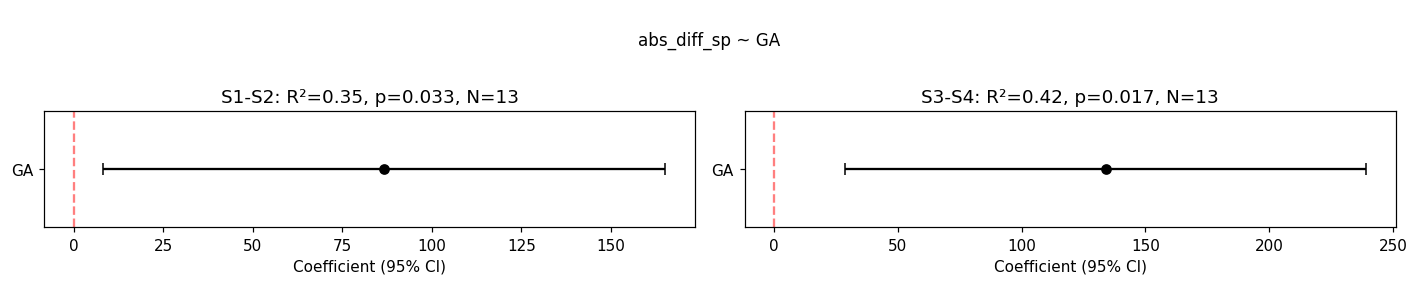

M_GA_thk (vol) | S1-S2: 13 subjects used
M_GA_thk (vol) | S3-S4: 13 subjects used


In [20]:
vol_results = {}

vol_results['M_GA_thk (vol)'] = fit_and_present(
    'abs_diff_sp', ['GA'], s12, s34,
    '', 'vol_M_GA_thksubj', ASSETS, save_tables=False,
)

for pair, (res, _) in vol_results['M_GA_thk (vol)'].items():
    print(f"M_GA_thk (vol) | {pair}: {int(res.nobs)} subjects used")


[M_GA_thk — SP volume baseline (thickness subset)] S1-S2 — top 3 outliers (|studentized residual|):
  1. FCB158/2019.07.07-034Y-MR_EI_Fetal_Neuro-29182  studentized_resid=+1.79  resid=+486  fitted=699  actual=1.19e+03
  2. 5552729/MR-EI_Fetal_Neuro-26149163-20210623  studentized_resid=+1.55  resid=+444  fitted=361  actual=806
  3. FCB155/2019.06.25-032Y-MR_EI_Fetal_Neuro-29190  studentized_resid=+1.26  resid=+352  fitted=278  actual=630

[M_GA_thk — SP volume baseline (thickness subset)] S3-S4 — top 3 outliers (|studentized residual|):
  1. FCB141/2019.04.03-032Y-MR_EI_Fetal_Neuro-29199  studentized_resid=+2.01  resid=+705  fitted=753  actual=1.46e+03
  2. FCB147/2019.05.08-036Y-MR_EI_Fetal_Neuro-29187  studentized_resid=+1.66  resid=+547  fitted=887  actual=1.43e+03
  3. FCB090/2016.07.24-029Y-MR_EI_Fetal_Neuro-12836  studentized_resid=-1.43  resid=-524  fitted=600  actual=76.5


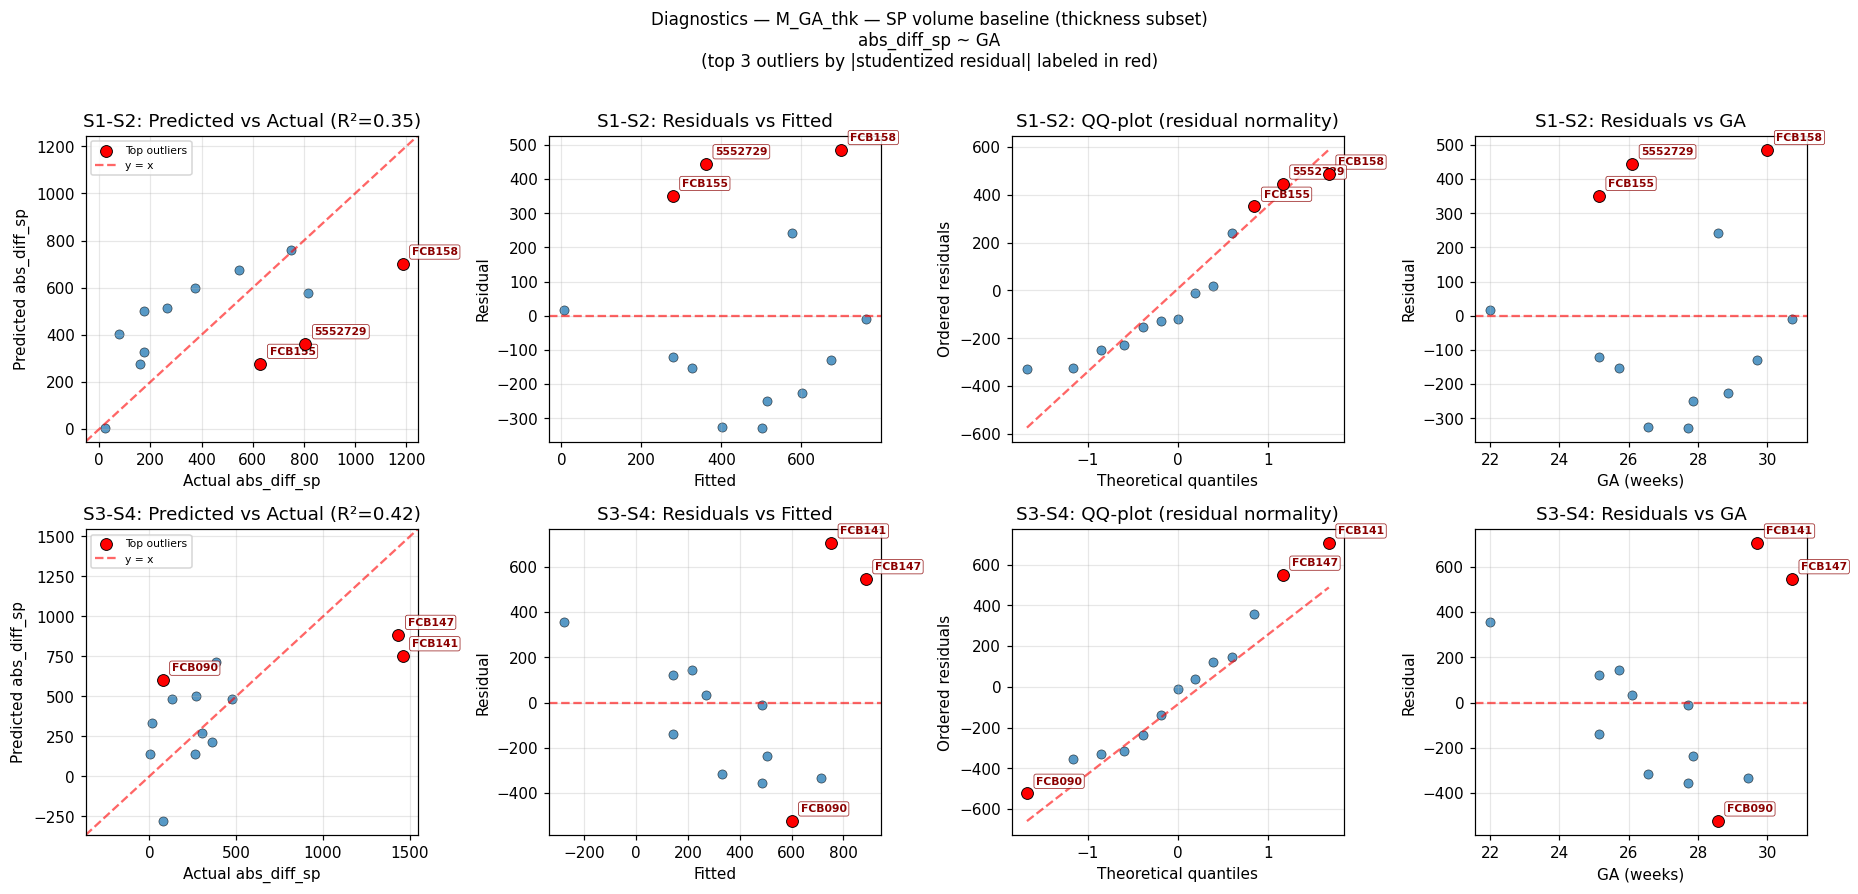

In [21]:
diagnostics_grid(
    vol_results['M_GA_thk (vol)'], s12, s34,
    'abs_diff_sp', ['GA'],
    'M_GA_thk — SP volume baseline (thickness subset)',
)
plt.show()


===  | S1-S2 | R²=0.632 | F=5.15 | p=0.0241 | N=13 ===


,Coef,SE,t,p,CI_low,CI_high,sig
const,-2692.860,990.607,-2.720,0.024,-4933.770,-451.950,*
GA,85.737,30.268,2.830,0.020,17.270,154.210,*
qa_mean,315.774,763.600,0.410,0.689,-1411.610,2043.160,
stack_count,76.427,33.870,2.260,0.050,-0.190,153.050,



===  | S3-S4 | R²=0.451 | F=2.47 | p=0.1288 | N=13 ===


,Coef,SE,t,p,CI_low,CI_high,sig
const,-3735.990,1549.500,-2.410,0.039,-7241.200,-230.780,*
GA,131.779,51.339,2.570,0.030,15.640,247.920,*
qa_mean,551.585,849.582,0.650,0.532,-1370.300,2473.470,
stack_count,29.223,47.338,0.620,0.552,-77.860,136.310,


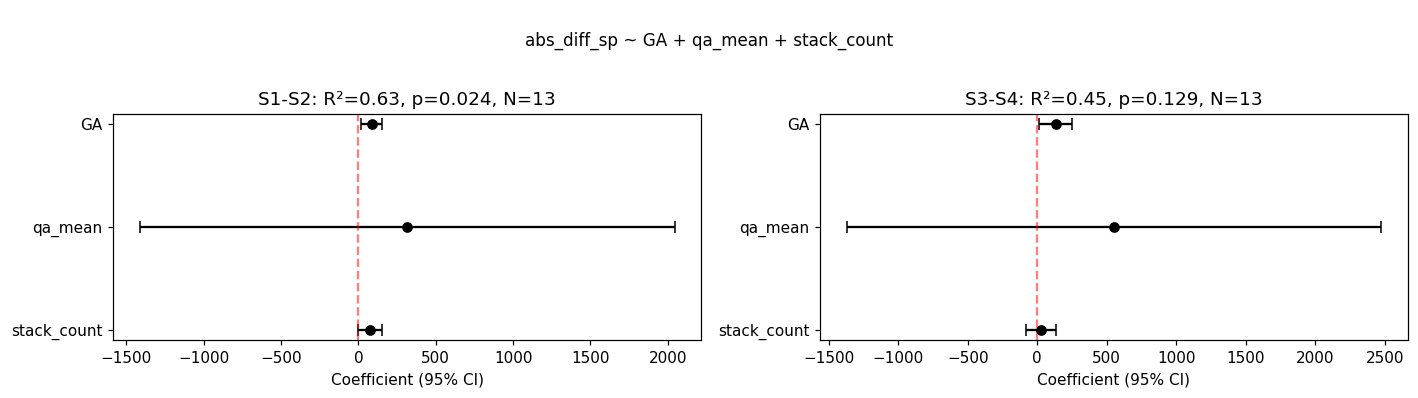

M_acq_thk (vol) | S1-S2: 13 subjects used
M_acq_thk (vol) | S3-S4: 13 subjects used


In [22]:
vol_results['M_acq_thk (vol)'] = fit_and_present(
    'abs_diff_sp', ['GA', 'qa_mean', 'stack_count'], s12, s34,
    '', 'vol_M_acq_thksubj', ASSETS, save_tables=False,
)

for pair, (res, _) in vol_results['M_acq_thk (vol)'].items():
    print(f"M_acq_thk (vol) | {pair}: {int(res.nobs)} subjects used")


[M_acq_thk — SP volume + acquisition factors (thickness subset)] S1-S2 — top 3 outliers (|studentized residual|):
  1. FCB158/2019.07.07-034Y-MR_EI_Fetal_Neuro-29182  studentized_resid=+1.86  resid=+416  fitted=769  actual=1.19e+03
  2. FCB105-B/2018.11.14-036Y-MR_EI_Fetal_Neuro-29459  studentized_resid=-1.29  resid=-298  fitted=564  actual=265
  3. FCB078/2016.03.04-036Y-MR_EI_Fetal_Neuro-7879  studentized_resid=-1.24  resid=-286  fitted=363  actual=77.7

[M_acq_thk — SP volume + acquisition factors (thickness subset)] S3-S4 — top 3 outliers (|studentized residual|):
  1. FCB141/2019.04.03-032Y-MR_EI_Fetal_Neuro-29199  studentized_resid=+1.88  resid=+699  fitted=759  actual=1.46e+03
  2. FCB114/2017.06.26-027Y-MR_EI_Fetal_Neuro-17914  studentized_resid=+1.60  resid=+385  fitted=-306  actual=78.9
  3. FCB090/2016.07.24-029Y-MR_EI_Fetal_Neuro-12836  studentized_resid=-1.56  resid=-577  fitted=654  actual=76.5


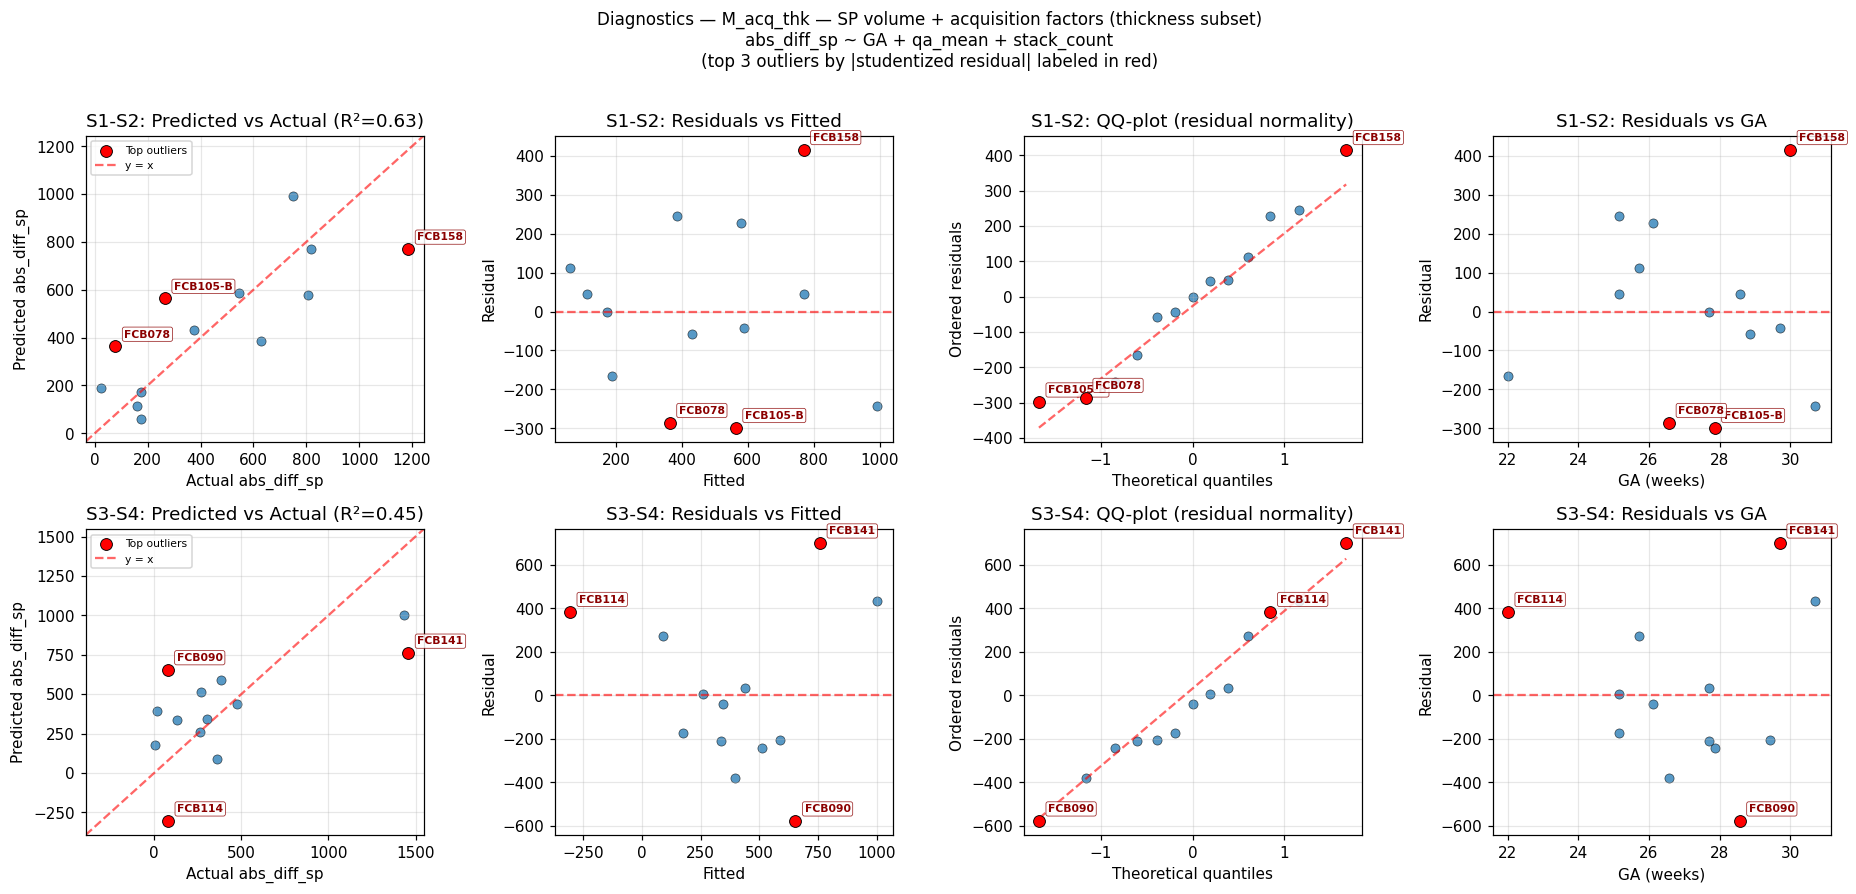

In [23]:
diagnostics_grid(
    vol_results['M_acq_thk (vol)'], s12, s34,
    'abs_diff_sp', ['GA', 'qa_mean', 'stack_count'],
    'M_acq_thk — SP volume + acquisition factors (thickness subset)',
)
plt.show()

## Surface area models

Same structure as the volume models, on the thickness subset:

1. **S_GA_thk**: `wm_surface_area_diff ~ GA`
2. **S_acq_thk**: `wm_surface_area_diff ~ GA + qa_mean + stack_count`


===  | S1-S2 | R²=0.002 | F=0.02 | p=0.8884 | N=13 ===


,Coef,SE,t,p,CI_low,CI_high,sig
const,48.047,301.560,0.160,0.876,-615.680,711.780,
GA,1.584,11.031,0.140,0.888,-22.700,25.860,



===  | S3-S4 | R²=0.246 | F=3.59 | p=0.0846 | N=13 ===


,Coef,SE,t,p,CI_low,CI_high,sig
const,-336.793,220.273,-1.530,0.155,-821.610,148.020,
GA,15.351,8.099,1.900,0.085,-2.470,33.180,


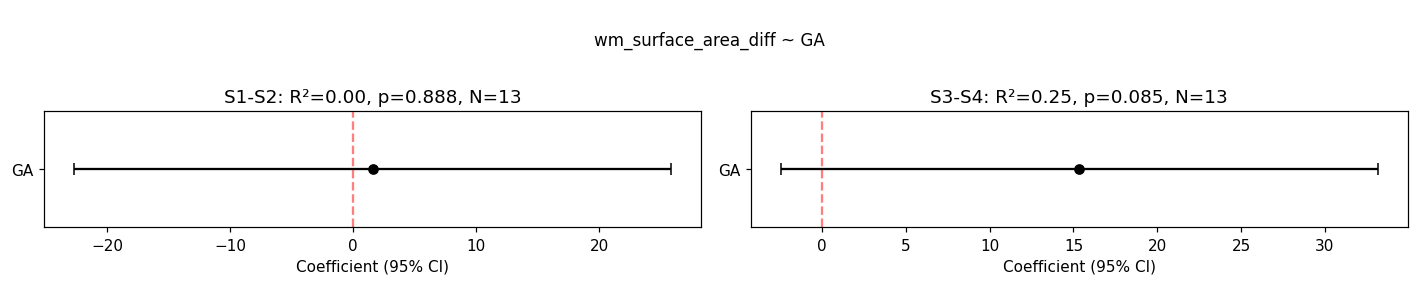

S_GA_thk (surf) | S1-S2: 13 subjects used
S_GA_thk (surf) | S3-S4: 13 subjects used


In [24]:
surf_results = {}

surf_results['S_GA_thk (surf)'] = fit_and_present(
    'wm_surface_area_diff', ['GA'], s12, s34,
    '', 'surf_S_GA_thksubj', ASSETS, save_tables=False,
)

for pair, (res, _) in surf_results['S_GA_thk (surf)'].items():
    print(f"S_GA_thk (surf) | {pair}: {int(res.nobs)} subjects used")


[S_GA_thk — WM surface area baseline (thickness subset)] S1-S2 — top 3 outliers (|studentized residual|):
  1. 5552729/MR-EI_Fetal_Neuro-26149163-20210623  studentized_resid=+2.21  resid=+196  fitted=89.4  actual=285
  2. FCB158/2019.07.07-034Y-MR_EI_Fetal_Neuro-29182  studentized_resid=+1.43  resid=+120  fitted=95.6  actual=216
  3. FCB139/2019.01.31-032Y-MR_EI_Fetal_Neuro-29172  studentized_resid=-1.06  resid=-93.2  fitted=93.8  actual=0.595

[S_GA_thk — WM surface area baseline (thickness subset)] S3-S4 — top 3 outliers (|studentized residual|):
  1. FCB117/2018.03.01-032Y-MR_EI_Fetal_Neuro-18053  studentized_resid=+2.14  resid=+129  fitted=115  actual=244
  2. FCB147/2019.05.08-036Y-MR_EI_Fetal_Neuro-29187  studentized_resid=-1.51  resid=-84.7  fitted=135  actual=50
  3. FCB114/2017.06.26-027Y-MR_EI_Fetal_Neuro-17914  studentized_resid=+1.37  resid=+65.2  fitted=0.934  actual=66.2


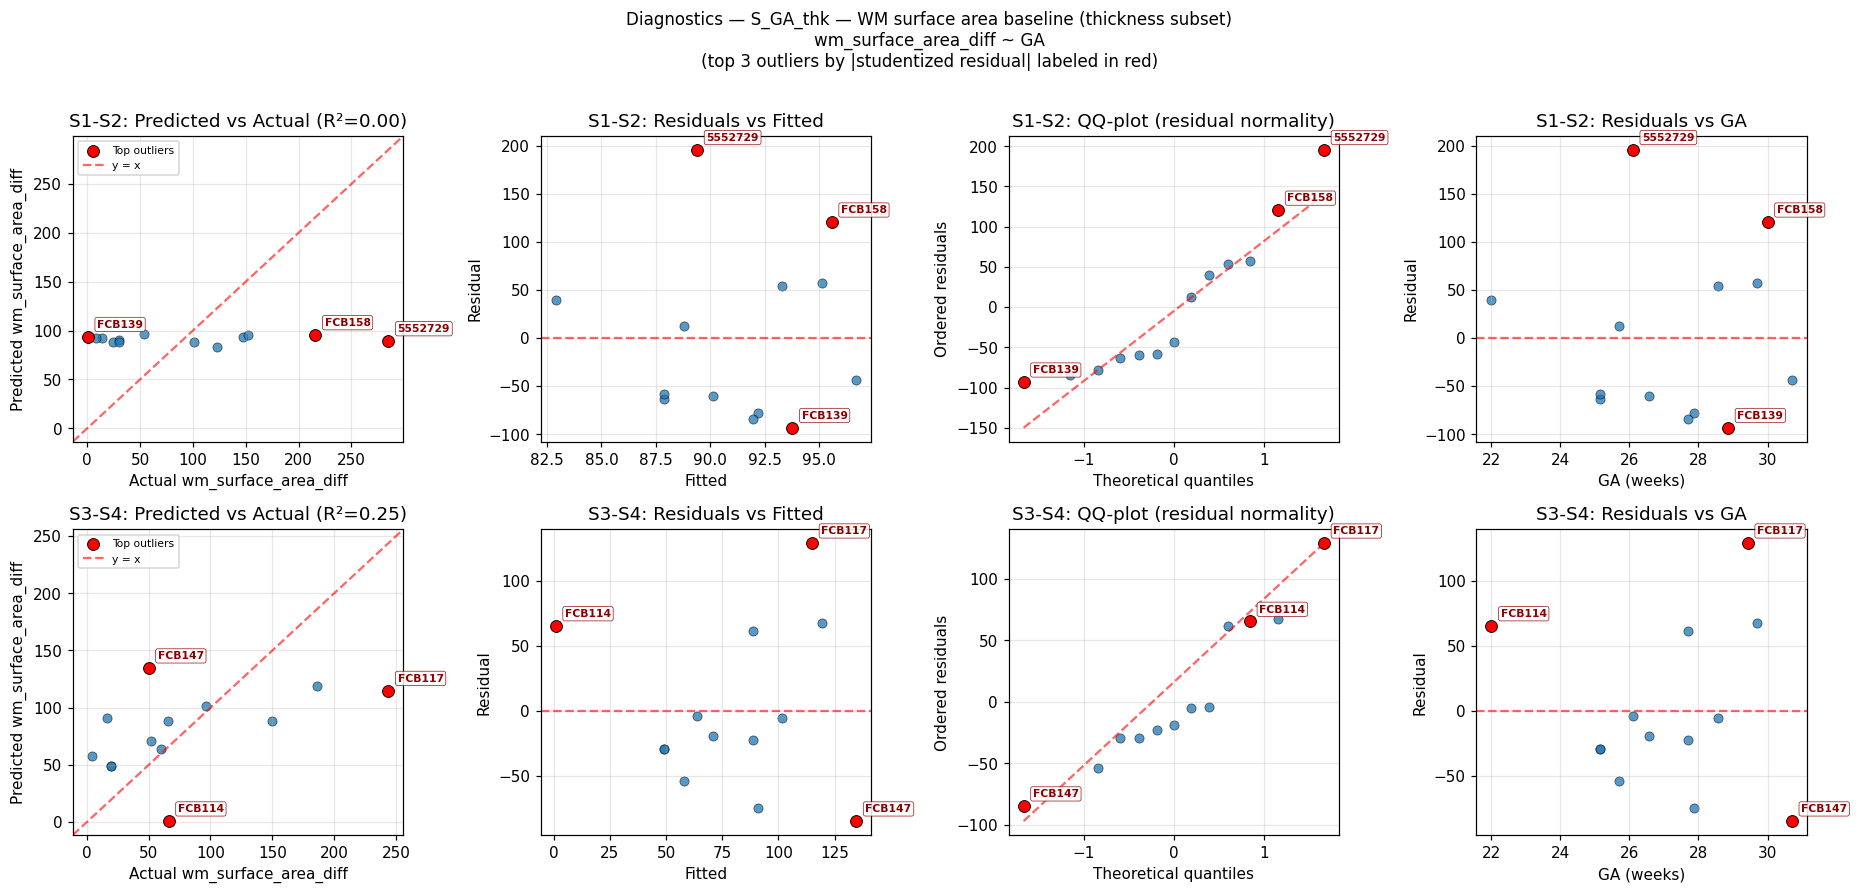

In [25]:
diagnostics_grid(
    surf_results['S_GA_thk (surf)'], s12, s34,
    'wm_surface_area_diff', ['GA'],
    'S_GA_thk — WM surface area baseline (thickness subset)',
)
plt.show()


===  | S1-S2 | R²=0.381 | F=1.85 | p=0.2085 | N=13 ===


,Coef,SE,t,p,CI_low,CI_high,sig
const,106.755,320.473,0.330,0.747,-618.210,831.720,
GA,4.266,9.792,0.440,0.673,-17.890,26.420,
qa_mean,-296.715,247.034,-1.200,0.260,-855.540,262.110,
stack_count,8.519,10.957,0.780,0.457,-16.270,33.310,



===  | S3-S4 | R²=0.543 | F=3.56 | p=0.0604 | N=13 ===


,Coef,SE,t,p,CI_low,CI_high,sig
const,-146.767,210.835,-0.700,0.504,-623.710,330.170,
GA,16.279,6.985,2.330,0.045,0.480,32.080,*
qa_mean,-278.875,115.599,-2.410,0.039,-540.380,-17.370,*
stack_count,-5.689,6.441,-0.880,0.400,-20.260,8.880,


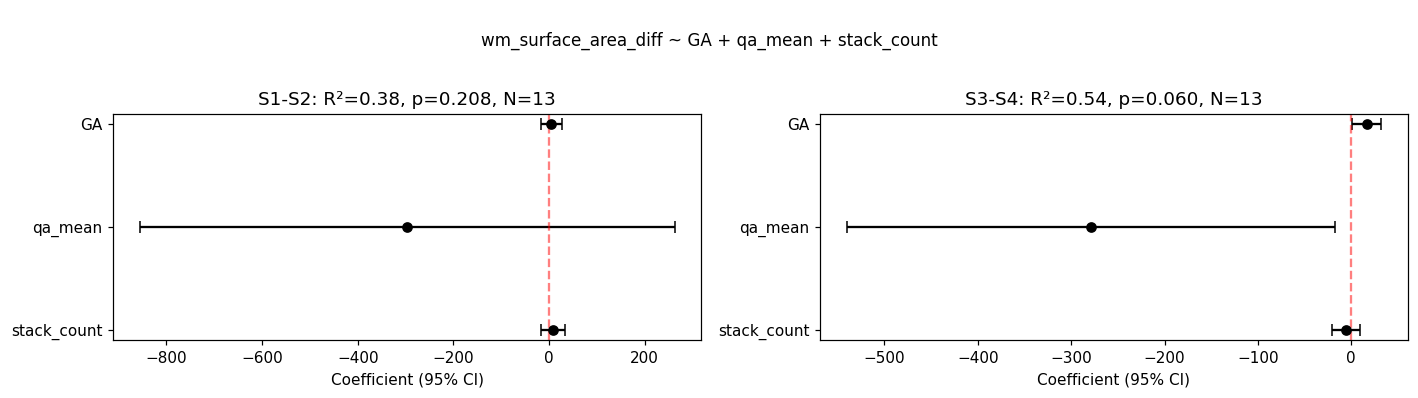

S_acq_thk (surf) | S1-S2: 13 subjects used
S_acq_thk (surf) | S3-S4: 13 subjects used


In [26]:
surf_results['S_acq_thk (surf)'] = fit_and_present(
    'wm_surface_area_diff', ['GA', 'qa_mean', 'stack_count'], s12, s34,
    '', 'surf_S_acq_thksubj', ASSETS, save_tables=False,
)

for pair, (res, _) in surf_results['S_acq_thk (surf)'].items():
    print(f"S_acq_thk (surf) | {pair}: {int(res.nobs)} subjects used")


[S_acq_thk — WM surface + acquisition factors (thickness subset)] S1-S2 — top 3 outliers (|studentized residual|):
  1. 5552729/MR-EI_Fetal_Neuro-26149163-20210623  studentized_resid=+2.14  resid=+154  fitted=131  actual=285
  2. FCB105-B/2018.11.14-036Y-MR_EI_Fetal_Neuro-29459  studentized_resid=-1.59  resid=-119  fitted=133  actual=14.3
  3. FCB158/2019.07.07-034Y-MR_EI_Fetal_Neuro-29182  studentized_resid=+1.31  resid=+94.5  fitted=122  actual=216

[S_acq_thk — WM surface + acquisition factors (thickness subset)] S3-S4 — top 3 outliers (|studentized residual|):
  1. FCB191/MR-EI_Fetal_Neuro-26708033-20230113  studentized_resid=-1.91  resid=-91.4  fitted=95.5  actual=4.17
  2. FCB141/2019.04.03-032Y-MR_EI_Fetal_Neuro-29199  studentized_resid=+1.56  resid=+79  fitted=107  actual=186
  3. FCB105-B/2018.11.14-036Y-MR_EI_Fetal_Neuro-29459  studentized_resid=-1.49  resid=-80.1  fitted=96.6  actual=16.5


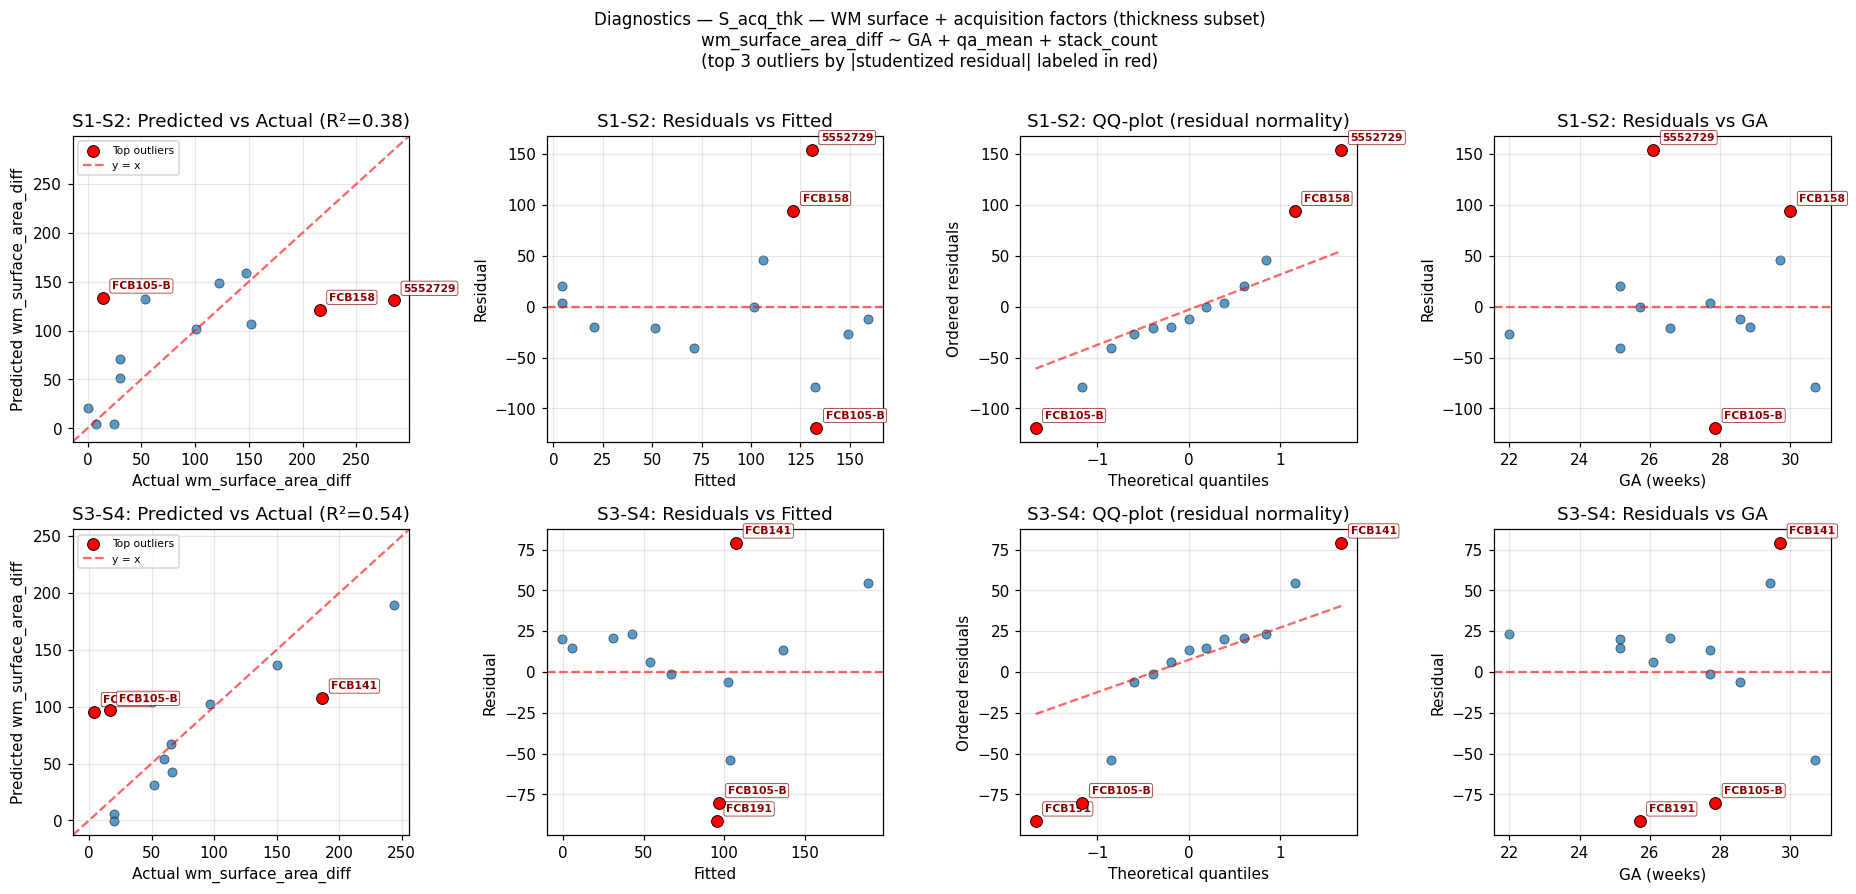

In [27]:
diagnostics_grid(
    surf_results['S_acq_thk (surf)'], s12, s34,
    'wm_surface_area_diff', ['GA', 'qa_mean', 'stack_count'],
    'S_acq_thk — WM surface + acquisition factors (thickness subset)',
)
plt.show()

## Thickness models

The **original** whole-brain SP thickness models from `paper_models.ipynb`, unchanged — they
were already fit on this same 13-subject sample. Included here so the cross-model comparison
below covers all three outcomes (volume, surface, thickness) on an identical sample.

1. **T_GA_thk**: `thk_diff ~ GA`
2. **T_acq_thk**: `thk_diff ~ GA + qa_mean + stack_count`


===  | S1-S2 | R²=0.313 | F=5.00 | p=0.0470 | N=13 ===


,Coef,SE,t,p,CI_low,CI_high,sig
const,-0.749,0.387,-1.940,0.079,-1.600,0.100,
GA,0.032,0.014,2.240,0.047,0.000,0.060,*



===  | S3-S4 | R²=0.276 | F=4.19 | p=0.0652 | N=13 ===


,Coef,SE,t,p,CI_low,CI_high,sig
const,-1.228,0.681,-1.800,0.099,-2.730,0.270,
GA,0.051,0.025,2.050,0.065,-0.000,0.110,


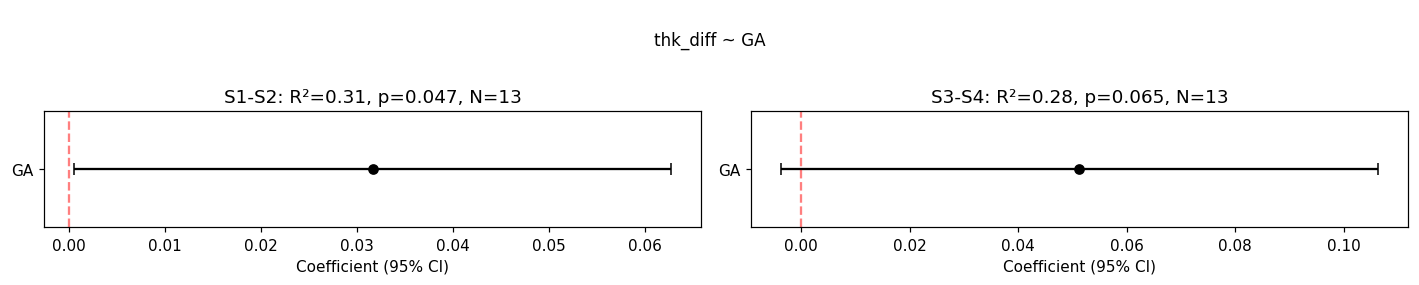

T_GA_thk (thk) | S1-S2: 13 subjects used
T_GA_thk (thk) | S3-S4: 13 subjects used


In [28]:
thk_results = {}

thk_results['T_GA_thk (thk)'] = fit_and_present(
    'thk_diff', ['GA'], thk_s12, thk_s34,
    '', 'thk_T_GA_thksubj', ASSETS, save_tables=False,
)

for pair, (res, _) in thk_results['T_GA_thk (thk)'].items():
    print(f"T_GA_thk (thk) | {pair}: {int(res.nobs)} subjects used")


[T_GA_thk — WB SP thickness baseline (thickness subset)] S1-S2 — top 3 outliers (|studentized residual|):
  1. FCB141/2019.04.03-032Y-MR_EI_Fetal_Neuro-29199  studentized_resid=+2.78  resid=+0.303  fitted=0.192  actual=0.495
  2. FCB090/2016.07.24-029Y-MR_EI_Fetal_Neuro-12836  studentized_resid=-1.30  resid=-0.147  fitted=0.156  actual=0.00872
  3. FCB114/2017.06.26-027Y-MR_EI_Fetal_Neuro-17914  studentized_resid=+1.03  resid=+0.0904  fitted=-0.0523  actual=0.038

[T_GA_thk — WB SP thickness baseline (thickness subset)] S3-S4 — top 3 outliers (|studentized residual|):
  1. FCB141/2019.04.03-032Y-MR_EI_Fetal_Neuro-29199  studentized_resid=+2.68  resid=+0.492  fitted=0.296  actual=0.788
  2. FCB147/2019.05.08-036Y-MR_EI_Fetal_Neuro-29187  studentized_resid=-1.38  resid=-0.238  fitted=0.347  actual=0.109
  3. FCB114/2017.06.26-027Y-MR_EI_Fetal_Neuro-17914  studentized_resid=+1.06  resid=+0.157  fitted=-0.0995  actual=0.0572


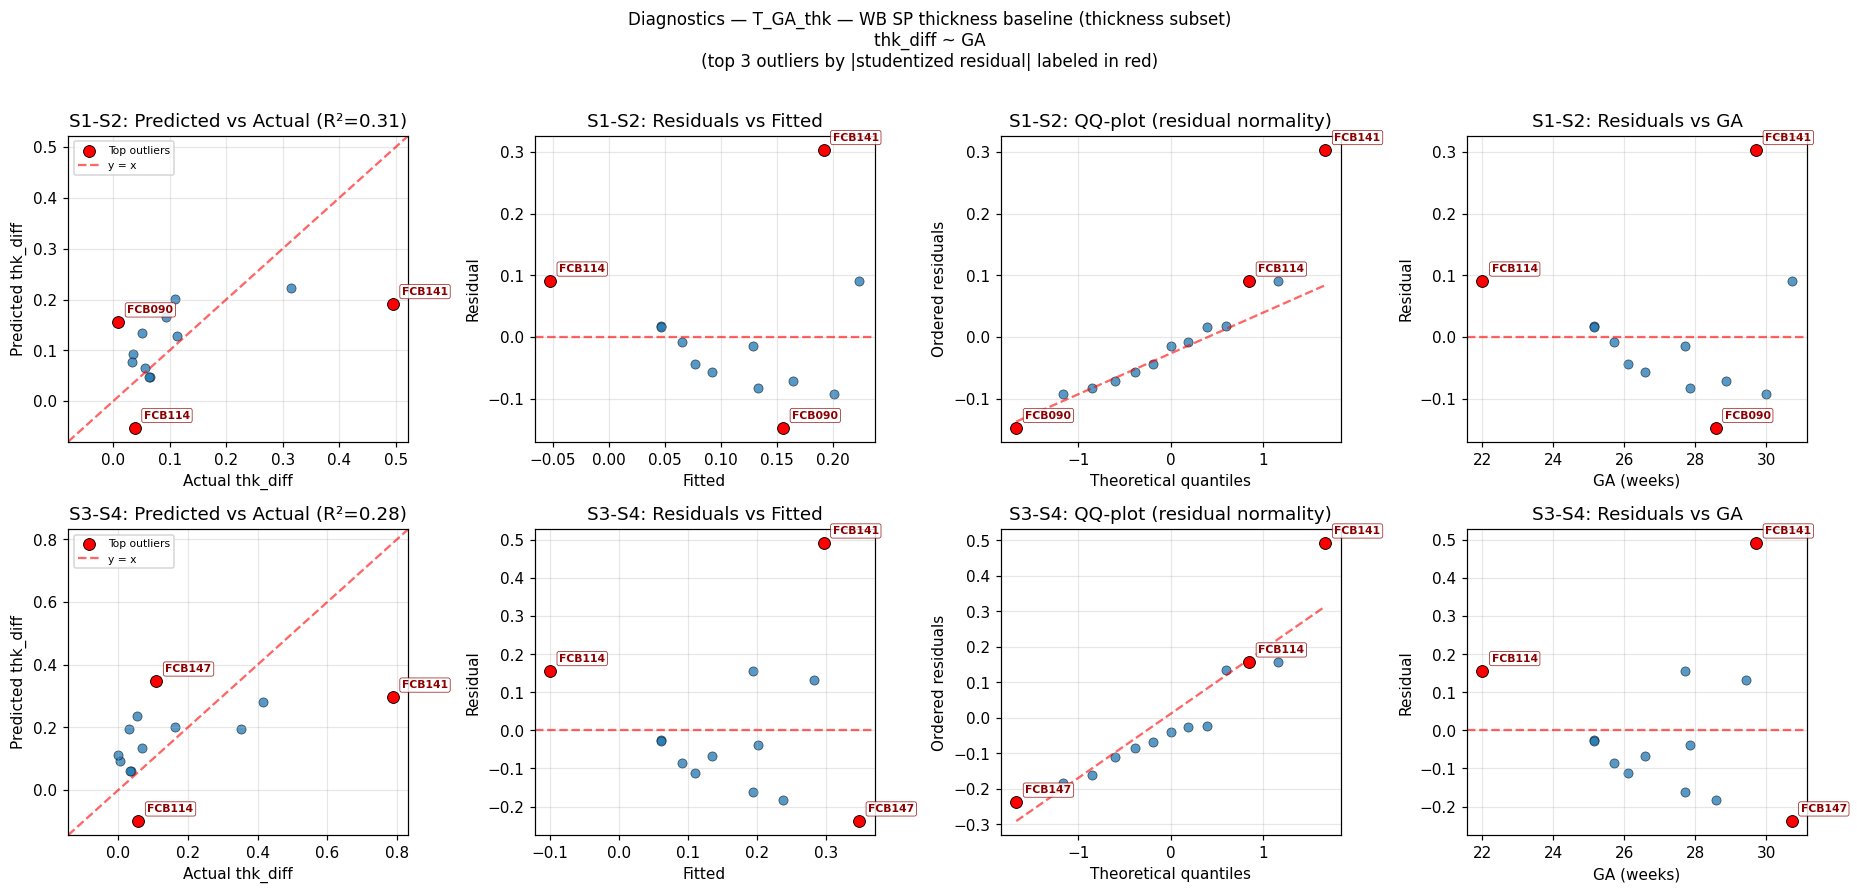

In [29]:
diagnostics_grid(
    thk_results['T_GA_thk (thk)'], thk_s12, thk_s34,
    'thk_diff', ['GA'],
    'T_GA_thk — WB SP thickness baseline (thickness subset)',
)
plt.show()


===  | S1-S2 | R²=0.326 | F=1.45 | p=0.2910 | N=13 ===


,Coef,SE,t,p,CI_low,CI_high,sig
const,-0.621,0.517,-1.200,0.260,-1.790,0.550,
GA,0.033,0.016,2.080,0.067,-0.000,0.070,
qa_mean,-0.163,0.398,-0.410,0.693,-1.060,0.740,
stack_count,-0.007,0.018,-0.370,0.721,-0.050,0.030,



===  | S3-S4 | R²=0.322 | F=1.43 | p=0.2984 | N=13 ===


,Coef,SE,t,p,CI_low,CI_high,sig
const,-1.000,0.810,-1.230,0.248,-2.830,0.830,
GA,0.052,0.027,1.940,0.084,-0.010,0.110,
qa_mean,-0.159,0.444,-0.360,0.729,-1.160,0.850,
stack_count,-0.019,0.025,-0.780,0.455,-0.080,0.040,


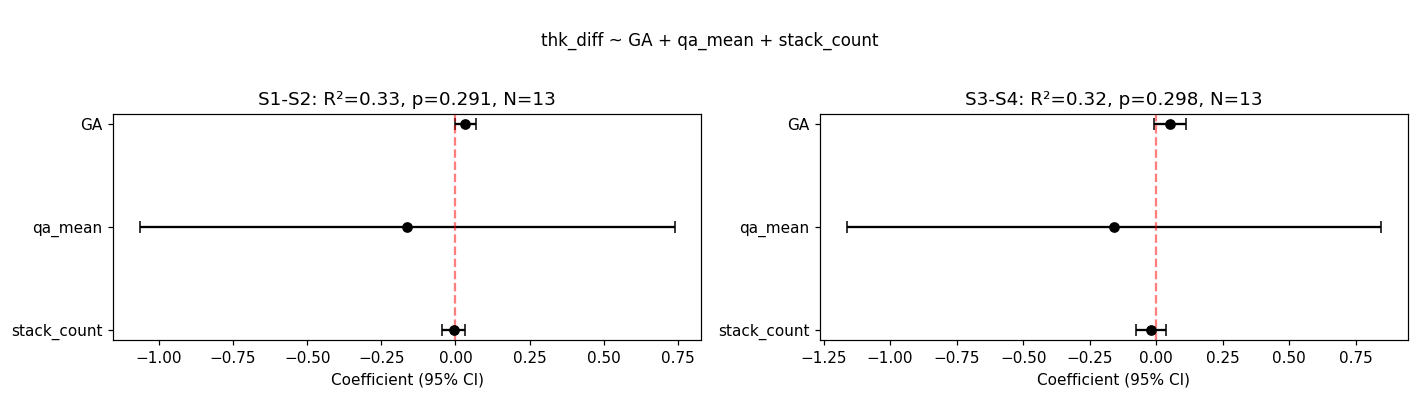

T_acq_thk (thk) | S1-S2: 13 subjects used
T_acq_thk (thk) | S3-S4: 13 subjects used


In [30]:
thk_results['T_acq_thk (thk)'] = fit_and_present(
    'thk_diff', ['GA', 'qa_mean', 'stack_count'], thk_s12, thk_s34,
    '', 'thk_T_acq_thksubj', ASSETS, save_tables=False,
)

for pair, (res, _) in thk_results['T_acq_thk (thk)'].items():
    print(f"T_acq_thk (thk) | {pair}: {int(res.nobs)} subjects used")


[T_acq_thk — WB SP thickness + acquisition factors (thickness subset)] S1-S2 — top 3 outliers (|studentized residual|):
  1. FCB141/2019.04.03-032Y-MR_EI_Fetal_Neuro-29199  studentized_resid=+2.53  resid=+0.288  fitted=0.207  actual=0.495
  2. FCB090/2016.07.24-029Y-MR_EI_Fetal_Neuro-12836  studentized_resid=-1.29  resid=-0.148  fitted=0.157  actual=0.00872
  3. FCB147/2019.05.08-036Y-MR_EI_Fetal_Neuro-29187  studentized_resid=+1.04  resid=+0.107  fitted=0.208  actual=0.314

[T_acq_thk — WB SP thickness + acquisition factors (thickness subset)] S3-S4 — top 3 outliers (|studentized residual|):
  1. FCB141/2019.04.03-032Y-MR_EI_Fetal_Neuro-29199  studentized_resid=+2.48  resid=+0.483  fitted=0.305  actual=0.788
  2. FCB114/2017.06.26-027Y-MR_EI_Fetal_Neuro-17914  studentized_resid=+1.46  resid=+0.184  fitted=-0.127  actual=0.0572
  3. FCB130/2018.11.02-030Y-MR_EI_Fetal_Neuro-29188  studentized_resid=-1.31  resid=-0.236  fitted=0.268  actual=0.0313


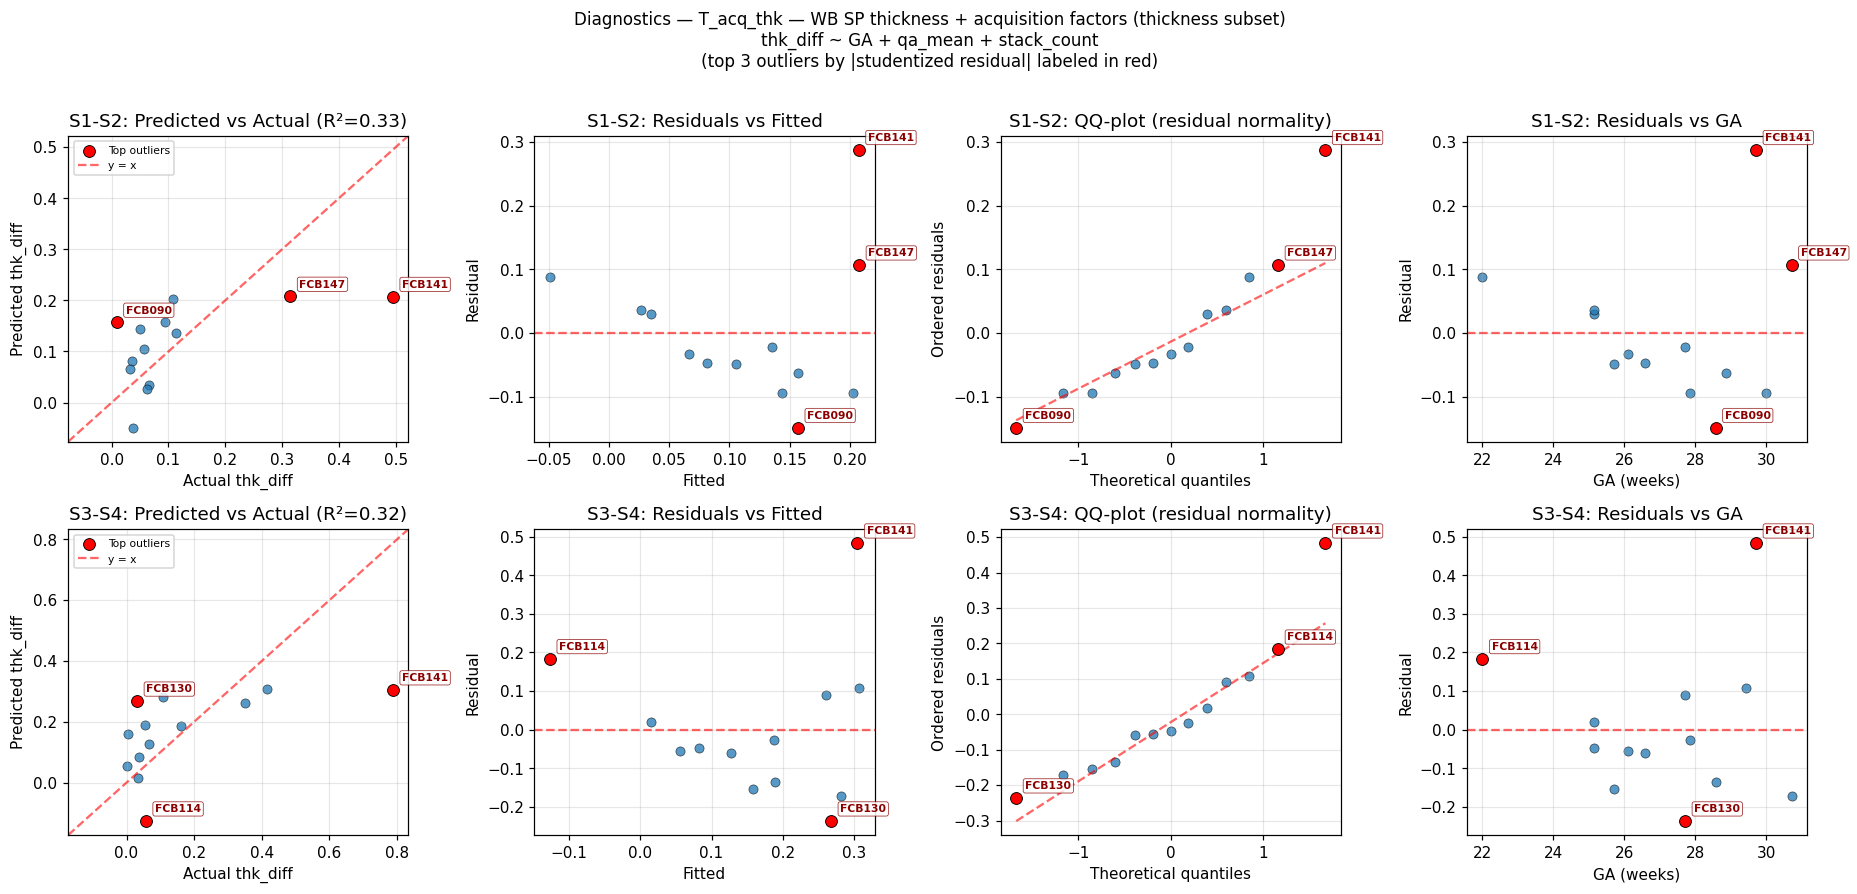

In [31]:
diagnostics_grid(
    thk_results['T_acq_thk (thk)'], thk_s12, thk_s34,
    'thk_diff', ['GA', 'qa_mean', 'stack_count'],
    'T_acq_thk — WB SP thickness + acquisition factors (thickness subset)',
)
plt.show()

## Thickness models — relative difference

The same two thickness models, but on the **relative** whole-brain SP thickness difference
(`apd_thk` = `|thk_a − thk_b| / thk_mean × 100`, the absolute percent difference) instead of
the absolute difference (`thk_diff`, mm). Same 13-subject sample.

1. **T_GA_rel_thk**: `apd_thk ~ GA`
2. **T_acq_rel_thk**: `apd_thk ~ GA + qa_mean + stack_count`


===  | S1-S2 | R²=0.223 | F=3.15 | p=0.1034 | N=13 ===


,Coef,SE,t,p,CI_low,CI_high,sig
const,-17.951,12.236,-1.470,0.170,-44.880,8.980,
GA,0.795,0.448,1.780,0.103,-0.190,1.780,



===  | S3-S4 | R²=0.246 | F=3.58 | p=0.0850 | N=13 ===


,Coef,SE,t,p,CI_low,CI_high,sig
const,-33.706,20.625,-1.630,0.130,-79.100,11.690,
GA,1.435,0.758,1.890,0.085,-0.230,3.100,


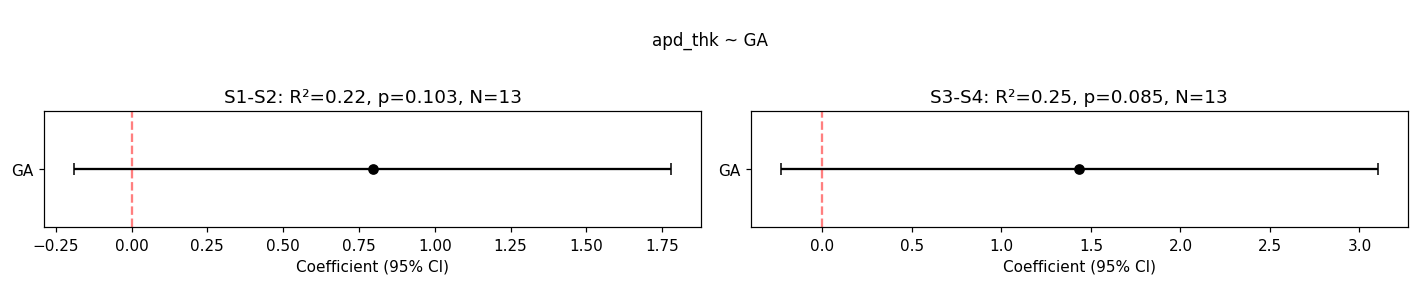

T_GA_rel_thk (thk) | S1-S2: 13 subjects used
T_GA_rel_thk (thk) | S3-S4: 13 subjects used


In [32]:
thk_rel_results = {}

thk_rel_results['T_GA_rel_thk (thk)'] = fit_and_present(
    'apd_thk', ['GA'], thk_s12, thk_s34,
    '', 'thk_T_GA_rel_thksubj', ASSETS, save_tables=False,
)

for pair, (res, _) in thk_rel_results['T_GA_rel_thk (thk)'].items():
    print(f"T_GA_rel_thk (thk) | {pair}: {int(res.nobs)} subjects used")


[T_GA_rel_thk — WB SP relative thickness baseline (thickness subset)] S1-S2 — top 3 outliers (|studentized residual|):
  1. FCB141/2019.04.03-032Y-MR_EI_Fetal_Neuro-29199  studentized_resid=+2.84  resid=+9.8  fitted=5.66  actual=15.5
  2. FCB090/2016.07.24-029Y-MR_EI_Fetal_Neuro-12836  studentized_resid=-1.25  resid=-4.47  fitted=4.76  actual=0.291
  3. FCB158/2019.07.07-034Y-MR_EI_Fetal_Neuro-29182  studentized_resid=-0.86  resid=-2.95  fitted=5.89  actual=2.95

[T_GA_rel_thk — WB SP relative thickness baseline (thickness subset)] S3-S4 — top 3 outliers (|studentized residual|):
  1. FCB141/2019.04.03-032Y-MR_EI_Fetal_Neuro-29199  studentized_resid=+2.58  resid=+14.4  fitted=8.93  actual=23.3
  2. FCB147/2019.05.08-036Y-MR_EI_Fetal_Neuro-29187  studentized_resid=-1.36  resid=-7.13  fitted=10.4  actual=3.24
  3. FCB114/2017.06.26-027Y-MR_EI_Fetal_Neuro-17914  studentized_resid=+1.13  resid=+5.05  fitted=-2.13  actual=2.92


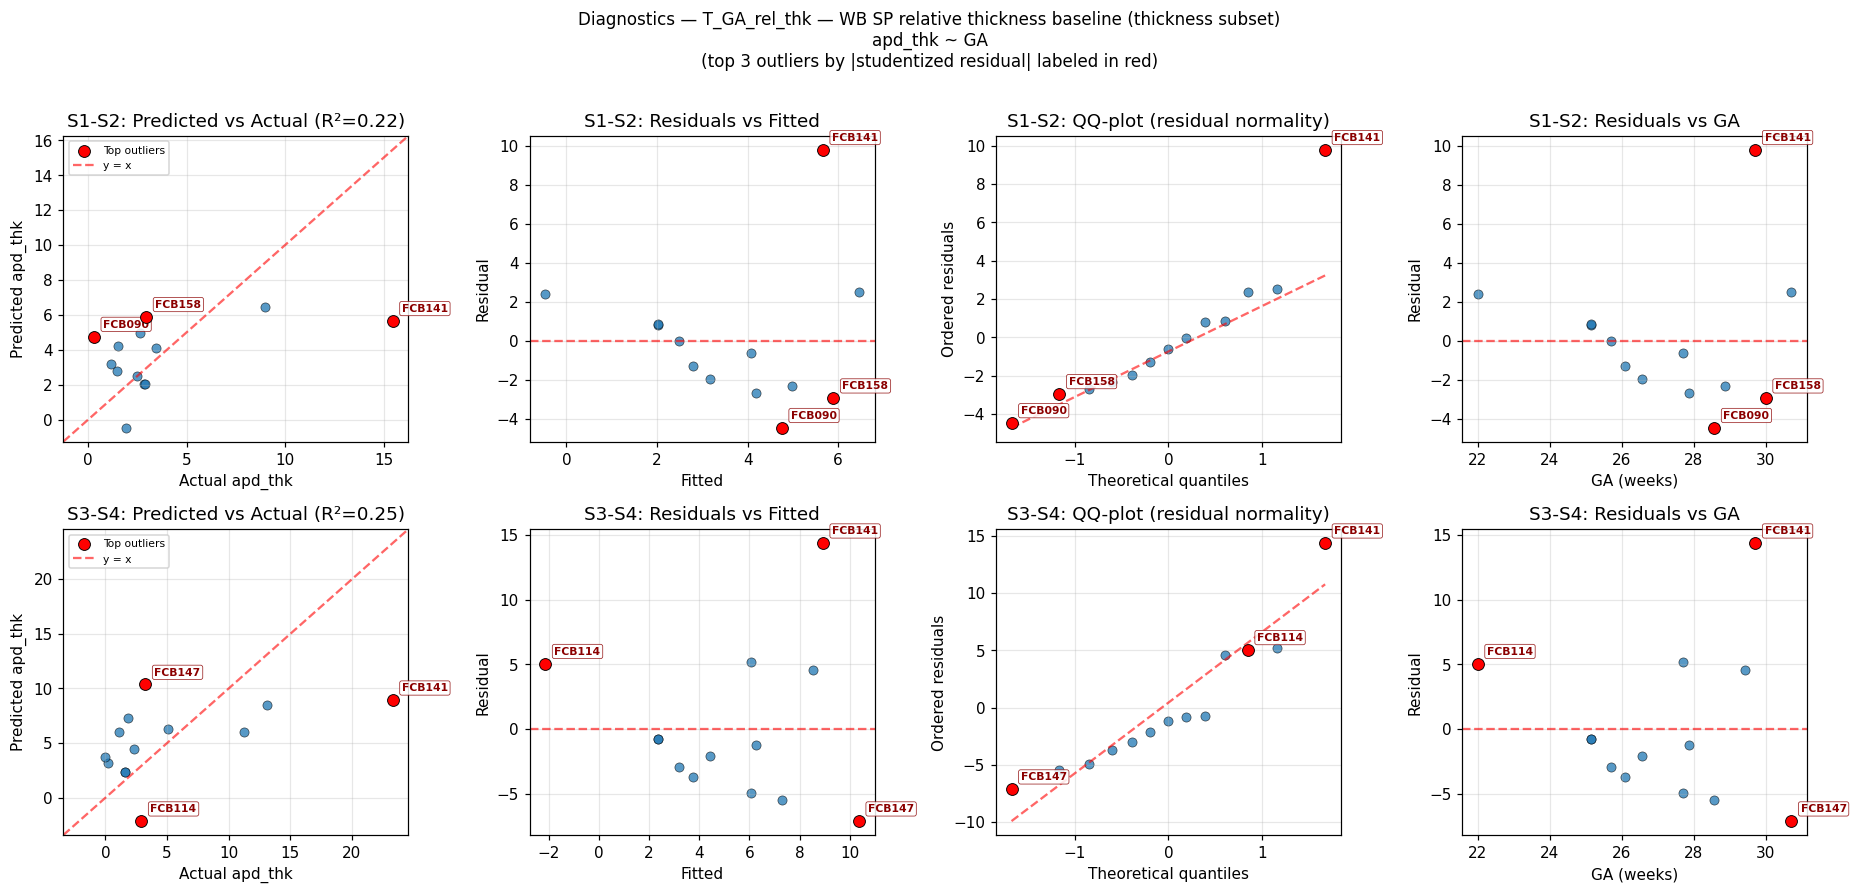

In [33]:
diagnostics_grid(
    thk_rel_results['T_GA_rel_thk (thk)'], thk_s12, thk_s34,
    'apd_thk', ['GA'],
    'T_GA_rel_thk — WB SP relative thickness baseline (thickness subset)',
)
plt.show()


===  | S1-S2 | R²=0.241 | F=0.95 | p=0.4554 | N=13 ===


,Coef,SE,t,p,CI_low,CI_high,sig
const,-13.582,16.322,-0.830,0.427,-50.500,23.340,
GA,0.835,0.499,1.670,0.128,-0.290,1.960,
qa_mean,-5.382,12.581,-0.430,0.679,-33.840,23.080,
stack_count,-0.233,0.558,-0.420,0.686,-1.500,1.030,



===  | S3-S4 | R²=0.295 | F=1.26 | p=0.3460 | N=13 ===


,Coef,SE,t,p,CI_low,CI_high,sig
const,-26.423,24.497,-1.080,0.309,-81.840,28.990,
GA,1.462,0.812,1.800,0.105,-0.370,3.300,
qa_mean,-5.417,13.432,-0.400,0.696,-35.800,24.970,
stack_count,-0.593,0.748,-0.790,0.448,-2.290,1.100,


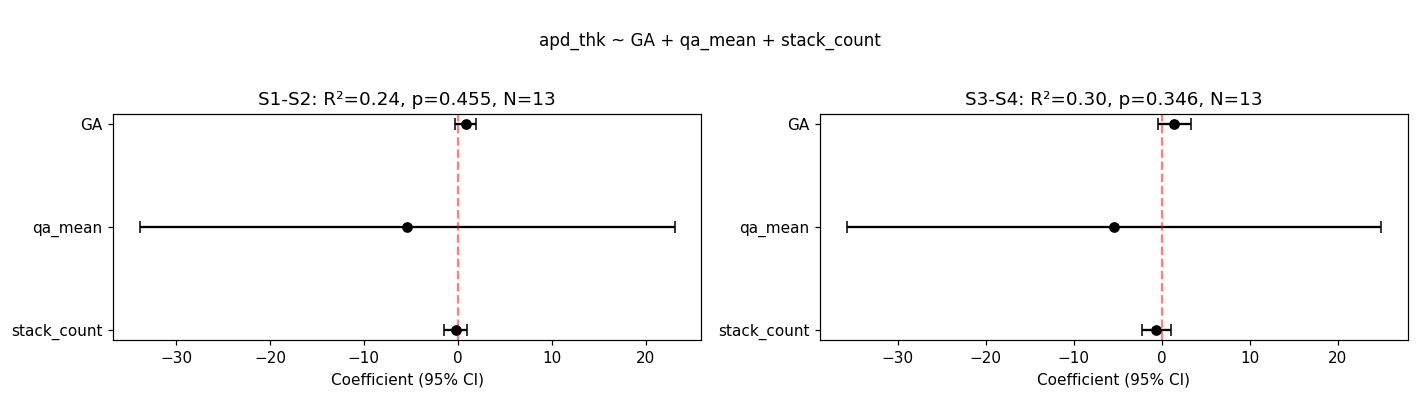

T_acq_rel_thk (thk) | S1-S2: 13 subjects used
T_acq_rel_thk (thk) | S3-S4: 13 subjects used


In [34]:
thk_rel_results['T_acq_rel_thk (thk)'] = fit_and_present(
    'apd_thk', ['GA', 'qa_mean', 'stack_count'], thk_s12, thk_s34,
    '', 'thk_T_acq_rel_thksubj', ASSETS, save_tables=False,
)

for pair, (res, _) in thk_rel_results['T_acq_rel_thk (thk)'].items():
    print(f"T_acq_rel_thk (thk) | {pair}: {int(res.nobs)} subjects used")


[T_acq_rel_thk — WB SP relative thickness + acquisition factors (thickness subset)] S1-S2 — top 3 outliers (|studentized residual|):
  1. FCB141/2019.04.03-032Y-MR_EI_Fetal_Neuro-29199  studentized_resid=+2.58  resid=+9.26  fitted=6.2  actual=15.5
  2. FCB090/2016.07.24-029Y-MR_EI_Fetal_Neuro-12836  studentized_resid=-1.23  resid=-4.46  fitted=4.75  actual=0.291
  3. FCB147/2019.05.08-036Y-MR_EI_Fetal_Neuro-29187  studentized_resid=+0.96  resid=+3.09  fitted=5.89  actual=8.98

[T_acq_rel_thk — WB SP relative thickness + acquisition factors (thickness subset)] S3-S4 — top 3 outliers (|studentized residual|):
  1. FCB141/2019.04.03-032Y-MR_EI_Fetal_Neuro-29199  studentized_resid=+2.40  resid=+14.1  fitted=9.17  actual=23.3
  2. FCB114/2017.06.26-027Y-MR_EI_Fetal_Neuro-17914  studentized_resid=+1.52  resid=+5.76  fitted=-2.85  actual=2.92
  3. FCB130/2018.11.02-030Y-MR_EI_Fetal_Neuro-29188  studentized_resid=-1.33  resid=-7.28  fitted=8.41  actual=1.13


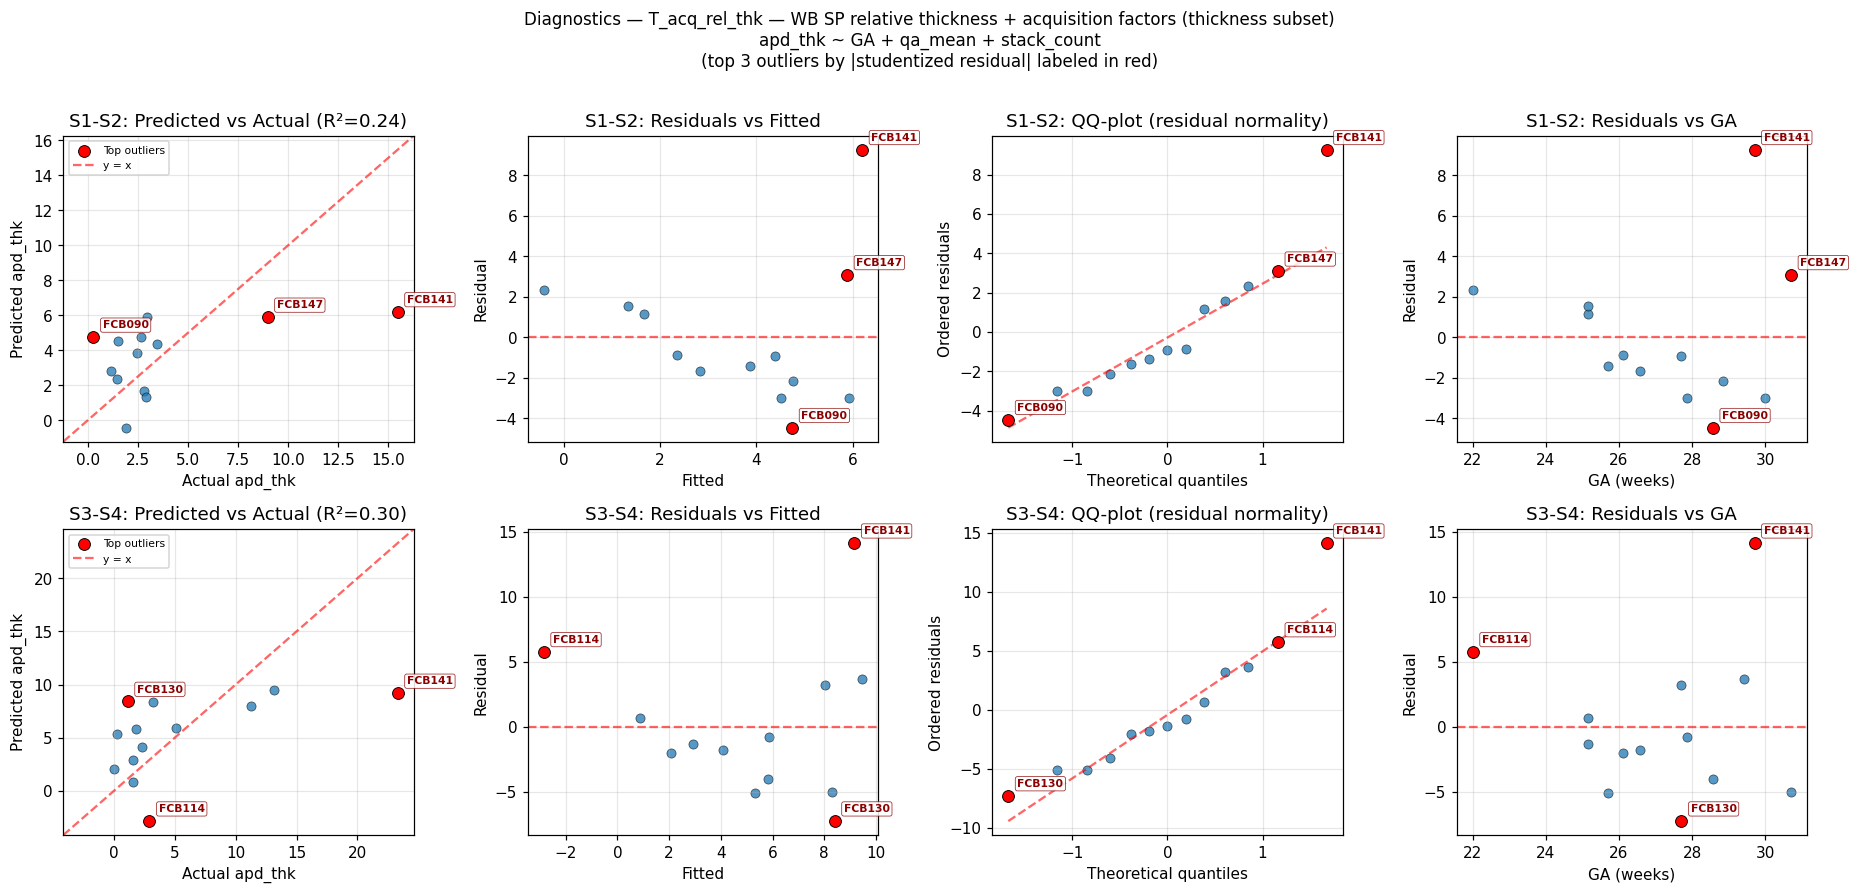

In [35]:
diagnostics_grid(
    thk_rel_results['T_acq_rel_thk (thk)'], thk_s12, thk_s34,
    'apd_thk', ['GA', 'qa_mean', 'stack_count'],
    'T_acq_rel_thk — WB SP relative thickness + acquisition factors (thickness subset)',
)
plt.show()

## Cross-model comparison

Side-by-side R², GA effect across all **eight** models (volume, surface, absolute thickness,
relative thickness) × both pairs, all fit on the same thickness subset (N = 13 per pair).

,model,pair,N,R2,adj_R2,F_p,GA_coef,GA_p
0,M_GA_thk (vol),S1-S2,13,0.349,0.290,0.034,86.688,0.034
1,M_GA_thk (vol),S3-S4,13,0.416,0.363,0.017,133.934,0.017
2,M_acq_thk (vol),S1-S2,13,0.632,0.509,0.024,85.737,0.020
3,M_acq_thk (vol),S3-S4,13,0.451,0.268,0.129,131.779,0.030
4,S_GA_thk (surf),S1-S2,13,0.002,-0.089,0.888,1.584,0.888
5,S_GA_thk (surf),S3-S4,13,0.246,0.178,0.085,15.351,0.085
6,S_acq_thk (surf),S1-S2,13,0.381,0.175,0.208,4.266,0.673
7,S_acq_thk (surf),S3-S4,13,0.543,0.390,0.060,16.279,0.045
8,T_GA_thk (thk),S1-S2,13,0.313,0.250,0.047,0.032,0.047
9,T_GA_thk (thk),S3-S4,13,0.276,0.210,0.065,0.051,0.065


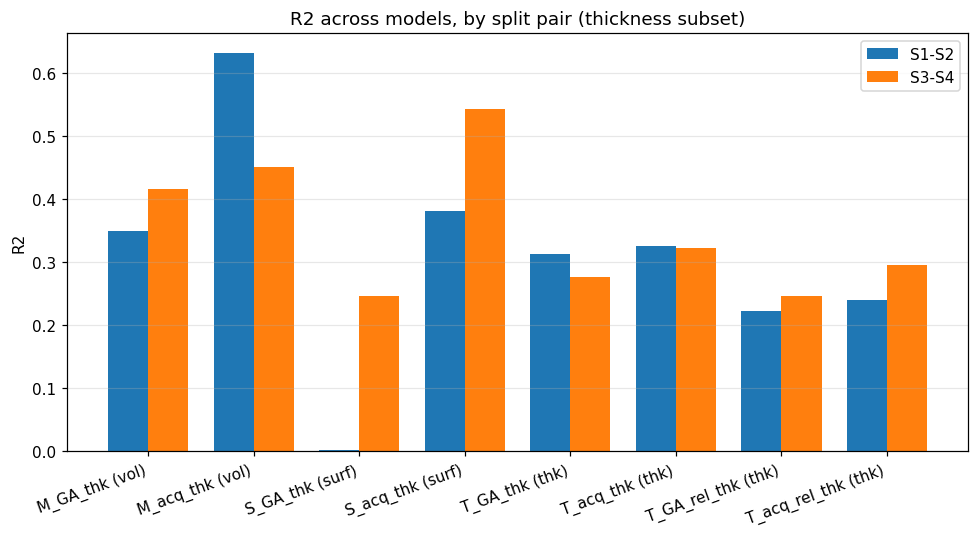

Saved -> assets/model_comparison_table_thk_subjects.csv, assets/model_comparison_R2_thk_subjects.png


In [36]:
all_results = {**vol_results, **surf_results, **thk_results, **thk_rel_results}
comparison = model_comparison_table(all_results)
comparison.to_csv(ASSETS / 'model_comparison_table_thk_subjects.csv', index=False)
display(comparison)

# R2 bar chart, paired by split
fig, ax = plt.subplots(figsize=(9, 5))
models = comparison['model'].unique()
x = np.arange(len(models))
w = 0.38
for i, pair in enumerate(['S1-S2', 'S3-S4']):
    sub = comparison[comparison['pair'] == pair].set_index('model').reindex(models)
    ax.bar(x + (i - 0.5) * w, sub['R2'], width=w, label=pair)
ax.set_xticks(x); ax.set_xticklabels(models, rotation=20, ha='right')
ax.set_ylabel('R2'); ax.set_title('R2 across models, by split pair (thickness subset)')
ax.legend(); ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
fig.savefig(ARTIFACTS / 'model_comparison_R2_thk_subjects.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved -> assets/model_comparison_table_thk_subjects.csv, '
      'assets/model_comparison_R2_thk_subjects.png')